In [1]:
!pip install medmnist -q

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import medmnist
from medmnist import PneumoniaMNIST, INFO
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("PyTorch version:", torch.__version__)
print("MedMNIST version:", medmnist.__version__)
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 6.8 MB/s eta 0:00:00
PyTorch version: 2.10.0+cu128
MedMNIST version: 3.0.2
Device: cuda


In [2]:

info = INFO['pneumoniamnist']
print("Dataset:", info['description'])
print("Number of classes:", len(info['label']))
print("Labels:", info['label'])
print("Image size:", info['n_channels'], "channel(s)")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])

train_dataset = PneumoniaMNIST(split='train', transform=transform, download=True)
val_dataset   = PneumoniaMNIST(split='val',   transform=transform, download=True)
test_dataset  = PneumoniaMNIST(split='test',  transform=transform, download=True)

print(f"\nTrain size : {len(train_dataset)}")
print(f"Val size   : {len(val_dataset)}")
print(f"Test size  : {len(test_dataset)}")

Dataset: The PneumoniaMNIST is based on a prior dataset of 5,856 pediatric chest X-Ray images. The task is binary-class classification of pneumonia against normal. We split the source training set with a ratio of 9:1 into training and validation set and use its source validation set as the test set. The source images are gray-scale, and their sizes are (384−2,916)×(127−2,713). We center-crop the images and resize them into 1×28×28.
Number of classes: 2
Labels: {'0': 'normal', '1': 'pneumonia'}
Image size: 1 channel(s)


100%|██████████| 4.17M/4.17M [00:06<00:00, 667kB/s]



Train size : 4708
Val size   : 524
Test size  : 624


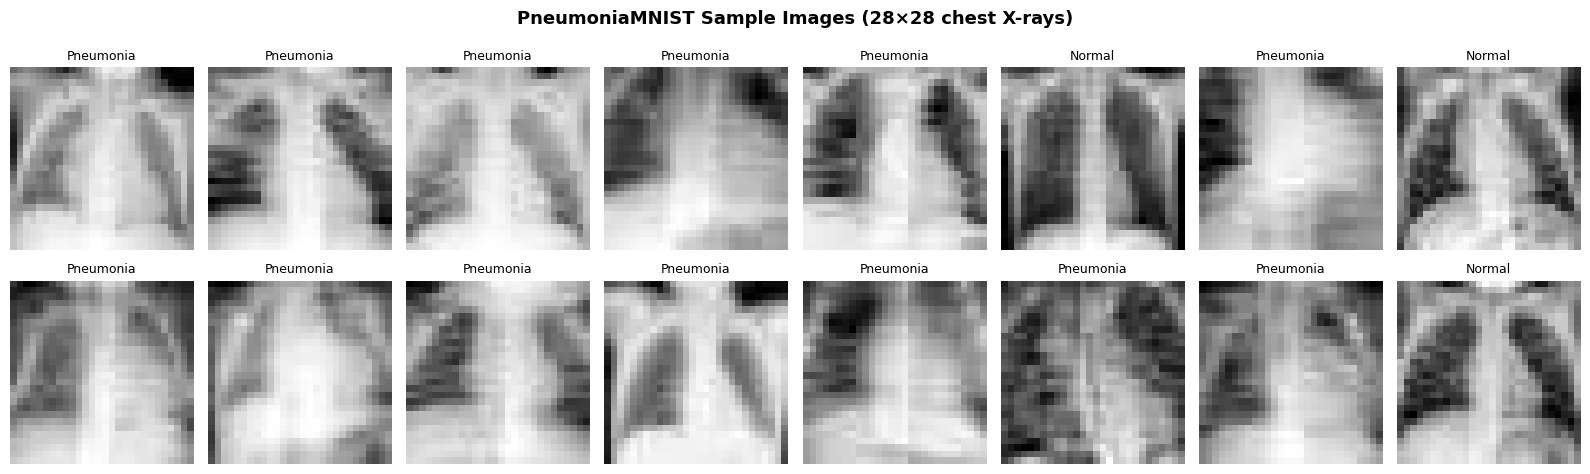

Class distribution in training set:
  Normal: 1214 images (25.8%)
  Pneumonia: 3494 images (74.2%)


In [3]:
#visualizing sample images
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
classes = {0: 'Normal', 1: 'Pneumonia'}

for i, ax in enumerate(axes.flat):
    img, label = train_dataset[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(classes[int(label)], fontsize=9)
    ax.axis('off')

plt.suptitle('PneumoniaMNIST Sample Images (28×28 chest X-rays)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print("Class distribution in training set:")
labels = [int(train_dataset[i][1]) for i in range(len(train_dataset))]
for k, v in classes.items():
    print(f"  {v}: {labels.count(k)} images ({labels.count(k)/len(labels)*100:.1f}%)")

In [4]:
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

#compute class weights to handle imbalance
n_normal    = 1214
n_pneumonia = 3494
n_total     = n_normal + n_pneumonia

weight_normal    = n_total / (2 * n_normal)
weight_pneumonia = n_total / (2 * n_pneumonia)
class_weights = torch.tensor([weight_normal, weight_pneumonia], dtype=torch.float32)

print(f"Batch size     : {BATCH_SIZE}")
print(f"Train batches  : {len(train_loader)}")
print(f"Val batches    : {len(val_loader)}")
print(f"Test batches   : {len(test_loader)}")
print(f"\nClass weights  : Normal={weight_normal:.4f}, Pneumonia={weight_pneumonia:.4f}")

#batch shape
imgs, labels = next(iter(train_loader))
print(f"\nBatch image shape : {imgs.shape}")
print(f"Batch label shape : {labels.shape}")

Batch size     : 64
Train batches  : 74
Val batches    : 9
Test batches   : 10

Class weights  : Normal=1.9390, Pneumonia=0.6737

Batch image shape : torch.Size([64, 1, 28, 28])
Batch label shape : torch.Size([64, 1])


In [5]:
#Manual implementation of cross-correlation, max-pooling, avg-pooling
import torch.nn.functional as F

#2D Cross-Correlation
def cross_correlation_2d(X, K):
    """Manual 2D cross-correlation (no padding, stride=1)"""
    kh, kw = K.shape
    oh = X.shape[0] - kh + 1
    ow = X.shape[1] - kw + 1
    output = torch.zeros((oh, ow))
    for i in range(oh):
        for j in range(ow):
            output[i, j] = (X[i:i+kh, j:j+kw] * K).sum()
    return output


def manual_max_pool(X, pool_size=2, stride=2):
    oh = (X.shape[0] - pool_size) // stride + 1
    ow = (X.shape[1] - pool_size) // stride + 1
    output = torch.zeros((oh, ow))
    for i in range(oh):
        for j in range(ow):
            output[i, j] = X[i*stride:i*stride+pool_size, j*stride:j*stride+pool_size].max()
    return output

#Manual Average Pooling
def manual_avg_pool(X, pool_size=2, stride=2):
    oh = (X.shape[0] - pool_size) // stride + 1
    ow = (X.shape[1] - pool_size) // stride + 1
    output = torch.zeros((oh, ow))
    for i in range(oh):
        for j in range(ow):
            output[i, j] = X[i*stride:i*stride+pool_size, j*stride:j*stride+pool_size].mean()
    return output

#Test on a sample image
sample_img = imgs[0].squeeze()  # shape: [28, 28]

# Simple edge-detection kernel
K = torch.tensor([[-1., 0., 1.],
                  [-2., 0., 2.],
                  [-1., 0., 1.]])

manual_out  = cross_correlation_2d(sample_img, K)
pytorch_out = F.conv2d(imgs[0].unsqueeze(0), K.unsqueeze(0).unsqueeze(0), padding=0).squeeze()

print("=== Cross-Correlation ===")
print(f"Input shape        : {sample_img.shape}")
print(f"Kernel shape       : {K.shape}")
print(f"Manual output size : {manual_out.shape}  → expected: (26×26)")
print(f"PyTorch output size: {pytorch_out.shape}")
print(f"Max difference (manual vs PyTorch): {(manual_out - pytorch_out).abs().max():.6f}")

print("\n=== Pooling ===")
manual_max = manual_max_pool(manual_out)
manual_avg = manual_avg_pool(manual_out)
print(f"After max-pool (2×2, stride=2) : {manual_max.shape}")
print(f"After avg-pool (2×2, stride=2) : {manual_avg.shape}")

#PyTorch pooling comparison
pt_max = F.max_pool2d(manual_out.unsqueeze(0).unsqueeze(0), 2, 2).squeeze()
pt_avg = F.avg_pool2d(manual_out.unsqueeze(0).unsqueeze(0), 2, 2).squeeze()
print(f"Max diff max-pool (manual vs PyTorch): {(manual_max - pt_max).abs().max():.6f}")
print(f"Max diff avg-pool (manual vs PyTorch): {(manual_avg - pt_avg).abs().max():.6f}")

=== Cross-Correlation ===
Input shape        : torch.Size([28, 28])
Kernel shape       : torch.Size([3, 3])
Manual output size : torch.Size([26, 26])  → expected: (26×26)
PyTorch output size: torch.Size([26, 26])
Max difference (manual vs PyTorch): 0.000000

=== Pooling ===
After max-pool (2×2, stride=2) : torch.Size([13, 13])
After avg-pool (2×2, stride=2) : torch.Size([13, 13])
Max diff max-pool (manual vs PyTorch): 0.000000
Max diff avg-pool (manual vs PyTorch): 0.000000


In [6]:
#manual calculations of output sizes
print("=" * 55)
print("MANUAL DIMENSIONAL CALCULATIONS")
print("=" * 55)

print("""
FORMULA: output_size = floor((N + 2P - F) / S) + 1
  N = input size, F = kernel size, P = padding, S = stride
""")

def conv_out(N, F, P=0, S=1):
    return (N + 2*P - F) // S + 1

def pool_out(N, F, S=None):
    if S is None: S = F
    return (N - F) // S + 1

print("--- LeNet-style CNN on 28×28 input ---\n")

# Conv1
N = 28
print(f"Input                        : {N}×{N}")
o1 = conv_out(N, F=5, P=2, S=1)
print(f"Conv1 (F=5, P=2, S=1)        : ({N}+2×2-5)/1+1 = {o1}×{o1}")
o1p = pool_out(o1, F=2, S=2)
print(f"MaxPool1 (F=2, S=2)          : ({o1}-2)/2+1    = {o1p}×{o1p}")

# Conv2
o2 = conv_out(o1p, F=5, P=0, S=1)
print(f"Conv2 (F=5, P=0, S=1)        : ({o1p}+0-5)/1+1  = {o2}×{o2}")
o2p = pool_out(o2, F=2, S=2)
print(f"MaxPool2 (F=2, S=2)          : ({o2}-2)/2+1    = {o2p}×{o2p}")

# Conv3 (1x1)
o3 = conv_out(o2p, F=1, P=0, S=1)
print(f"Conv3 1×1 (F=1, P=0, S=1)   : ({o2p}+0-1)/1+1  = {o3}×{o3}")

print(f"\nFlatten → {o3}×{o3}×32 = {o3*o3*32} features (example with 32 filters)")

print("\n--- Effect of Stride ---")
for s in [1, 2, 3]:
    o = conv_out(28, F=3, P=1, S=s)
    print(f"  Conv(F=3, P=1, S={s}) on 28×28 → {o}×{o}")

print("\n--- Effect of Padding ---")
for p in [0, 1, 2]:
    o = conv_out(28, F=3, P=p, S=1)
    print(f"  Conv(F=3, P={p}, S=1) on 28×28 → {o}×{o}")

print("\n--- Effect of Pooling type (same formula) ---")
print(f"  MaxPool(F=2,S=2) on 14×14 → {pool_out(14,2,2)}×{pool_out(14,2,2)}")
print(f"  AvgPool(F=2,S=2) on 14×14 → {pool_out(14,2,2)}×{pool_out(14,2,2)}")
print(f"  MaxPool(F=3,S=2) on 14×14 → {pool_out(14,3,2)}×{pool_out(14,3,2)}")

MANUAL DIMENSIONAL CALCULATIONS

FORMULA: output_size = floor((N + 2P - F) / S) + 1
  N = input size, F = kernel size, P = padding, S = stride

--- LeNet-style CNN on 28×28 input ---

Input                        : 28×28
Conv1 (F=5, P=2, S=1)        : (28+2×2-5)/1+1 = 28×28
MaxPool1 (F=2, S=2)          : (28-2)/2+1    = 14×14
Conv2 (F=5, P=0, S=1)        : (14+0-5)/1+1  = 10×10
MaxPool2 (F=2, S=2)          : (10-2)/2+1    = 5×5
Conv3 1×1 (F=1, P=0, S=1)   : (5+0-1)/1+1  = 5×5

Flatten → 5×5×32 = 800 features (example with 32 filters)

--- Effect of Stride ---
  Conv(F=3, P=1, S=1) on 28×28 → 28×28
  Conv(F=3, P=1, S=2) on 28×28 → 14×14
  Conv(F=3, P=1, S=3) on 28×28 → 10×10

--- Effect of Padding ---
  Conv(F=3, P=0, S=1) on 28×28 → 26×26
  Conv(F=3, P=1, S=1) on 28×28 → 28×28
  Conv(F=3, P=2, S=1) on 28×28 → 30×30

--- Effect of Pooling type (same formula) ---
  MaxPool(F=2,S=2) on 14×14 → 7×7
  AvgPool(F=2,S=2) on 14×14 → 7×7
  MaxPool(F=3,S=2) on 14×14 → 6×6


In [7]:
# simple MLP baseline on image data
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

class MLPBaseline(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        return self.net(x)

mlp_model = MLPBaseline().to(device)
print(mlp_model)
print(f"\nTotal parameters: {sum(p.numel() for p in mlp_model.parameters()):,}")

Using device: cuda
MLPBaseline(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.3, inplace=False)
    (7): Linear(in_features=128, out_features=2, bias=True)
  )
)

Total parameters: 234,114


In [8]:
#Generic training & evaluation functions
def train_model(model, train_loader, val_loader, epochs=15, lr=1e-3):
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        # --- Training ---
        model.train()
        total_loss, correct, total = 0, 0, 0
        for imgs, labels in train_loader:
            imgs   = imgs.to(device)
            labels = labels.squeeze().long().to(device)
            optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            correct    += (out.argmax(1) == labels).sum().item()
            total      += labels.size(0)

        train_loss = total_loss / len(train_loader)
        train_acc  = correct / total

        # --- Validation ---
        model.eval()
        total_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs   = imgs.to(device)
                labels = labels.squeeze().long().to(device)
                out    = model(imgs)
                loss   = criterion(out, labels)
                total_loss += loss.item()
                correct    += (out.argmax(1) == labels).sum().item()
                total      += labels.size(0)

        val_loss = total_loss / len(val_loader)
        val_acc  = correct / total

        scheduler.step()
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f"Epoch [{epoch+1:2d}/{epochs}] "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    return history


def evaluate_model(model, loader, model_name="Model"):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs   = imgs.to(device)
            labels = labels.squeeze().long()
            out    = model(imgs)
            preds  = out.argmax(1).cpu()
            all_preds.extend(preds.numpy())
            all_labels.extend(labels.numpy())

    acc  = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average='weighted')
    rec  = recall_score(all_labels, all_preds, average='weighted')
    f1   = f1_score(all_labels, all_preds, average='weighted')
    cm   = confusion_matrix(all_labels, all_preds)

    print(f"\n=== {model_name} — Test Metrics ===")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"  Confusion Matrix:\n{cm}")

    return {'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1, 'cm': cm,
            'preds': all_preds, 'labels': all_labels}

In [10]:

print("Training MLP Baseline...")
print("=" * 60)
mlp_history = train_model(mlp_model, train_loader, val_loader, epochs=15, lr=1e-3)

Training MLP Baseline...
Epoch [ 1/15] Train Loss: 0.2127 Acc: 0.9189 | Val Loss: 0.1991 Acc: 0.8798
Epoch [ 2/15] Train Loss: 0.1500 Acc: 0.9441 | Val Loss: 0.1828 Acc: 0.8893
Epoch [ 3/15] Train Loss: 0.1467 Acc: 0.9431 | Val Loss: 0.1402 Acc: 0.9408
Epoch [ 4/15] Train Loss: 0.1270 Acc: 0.9480 | Val Loss: 0.1180 Acc: 0.9504
Epoch [ 5/15] Train Loss: 0.1204 Acc: 0.9537 | Val Loss: 0.1299 Acc: 0.9256
Epoch [ 6/15] Train Loss: 0.1019 Acc: 0.9624 | Val Loss: 0.1067 Acc: 0.9466
Epoch [ 7/15] Train Loss: 0.0925 Acc: 0.9656 | Val Loss: 0.1063 Acc: 0.9523
Epoch [ 8/15] Train Loss: 0.0907 Acc: 0.9647 | Val Loss: 0.1066 Acc: 0.9542
Epoch [ 9/15] Train Loss: 0.0812 Acc: 0.9705 | Val Loss: 0.1161 Acc: 0.9504
Epoch [10/15] Train Loss: 0.0775 Acc: 0.9703 | Val Loss: 0.1048 Acc: 0.9466
Epoch [11/15] Train Loss: 0.0716 Acc: 0.9730 | Val Loss: 0.1142 Acc: 0.9542
Epoch [12/15] Train Loss: 0.0693 Acc: 0.9718 | Val Loss: 0.1145 Acc: 0.9504
Epoch [13/15] Train Loss: 0.0696 Acc: 0.9739 | Val Loss: 0.1161

In [11]:
#leNet-inspired CNN with improvements for PneumoniaMNIST
class LeNetCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # Feature extractor
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 16, kernel_size=5, padding=2),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 2
            nn.Conv2d(16, 32, kernel_size=5, padding=0),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 3 — 1×1 convolution
            nn.Conv2d(32, 32, kernel_size=1),
            nn.ReLU(),
        )

        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(800, 120),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(120, 84),
            nn.ReLU(),
            nn.Linear(84, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

cnn_model = LeNetCNN().to(device)
print(cnn_model)
print(f"\nTotal parameters: {sum(p.numel() for p in cnn_model.parameters()):,}")
print(f"MLP parameters : 234,114")
print(f"CNN parameters : {sum(p.numel() for p in cnn_model.parameters()):,}")

LeNetCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
    (9): ReLU()
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=800, out_features=120, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=120, out_features=84, bias=True)
    (5): ReLU()
    (6): Linear(in_features=84, out_features=2, bias=True)
  )
)

Total parameters: 120,854
MLP parameters : 2

In [12]:

#Train LeNet CNN
print("Training LeNet CNN...")
print("=" * 60)
cnn_history = train_model(cnn_model, train_loader, val_loader, epochs=15, lr=1e-3)

# Save best model
torch.save(cnn_model.state_dict(), 'lenet_pneumonia.pth')
print("\nModel saved to lenet_pneumonia.pth")

Training LeNet CNN...
Epoch [ 1/15] Train Loss: 0.2419 Acc: 0.8845 | Val Loss: 0.1486 Acc: 0.9218
Epoch [ 2/15] Train Loss: 0.1119 Acc: 0.9543 | Val Loss: 0.0908 Acc: 0.9637
Epoch [ 3/15] Train Loss: 0.0817 Acc: 0.9711 | Val Loss: 0.0889 Acc: 0.9618
Epoch [ 4/15] Train Loss: 0.0765 Acc: 0.9720 | Val Loss: 0.1353 Acc: 0.9294
Epoch [ 5/15] Train Loss: 0.0650 Acc: 0.9743 | Val Loss: 0.0981 Acc: 0.9656
Epoch [ 6/15] Train Loss: 0.0453 Acc: 0.9841 | Val Loss: 0.0774 Acc: 0.9695
Epoch [ 7/15] Train Loss: 0.0320 Acc: 0.9900 | Val Loss: 0.1247 Acc: 0.9599
Epoch [ 8/15] Train Loss: 0.0292 Acc: 0.9883 | Val Loss: 0.0864 Acc: 0.9618
Epoch [ 9/15] Train Loss: 0.0194 Acc: 0.9936 | Val Loss: 0.1205 Acc: 0.9637
Epoch [10/15] Train Loss: 0.0260 Acc: 0.9902 | Val Loss: 0.1121 Acc: 0.9656
Epoch [11/15] Train Loss: 0.0133 Acc: 0.9955 | Val Loss: 0.1248 Acc: 0.9695
Epoch [12/15] Train Loss: 0.0115 Acc: 0.9960 | Val Loss: 0.1419 Acc: 0.9676
Epoch [13/15] Train Loss: 0.0085 Acc: 0.9979 | Val Loss: 0.1242 Ac

In [13]:
#Evaluate MLP and CNN on test set
mlp_results = evaluate_model(mlp_model, test_loader, "MLP Baseline")
cnn_results = evaluate_model(cnn_model, test_loader, "LeNet CNN")

# Summary comparison table
print("\n" + "=" * 50)
print(f"{'Metric':<15} {'MLP':>10} {'CNN':>10}")
print("=" * 50)
for metric in ['acc', 'prec', 'rec', 'f1']:
    print(f"{metric.capitalize():<15} {mlp_results[metric]:>10.4f} {cnn_results[metric]:>10.4f}")
print(f"{'Parameters':<15} {'234,114':>10} {'120,854':>10}")
print("=" * 50)


=== MLP Baseline — Test Metrics ===
  Accuracy  : 0.8926
  Precision : 0.8984
  Recall    : 0.8926
  F1-Score  : 0.8897
  Confusion Matrix:
[[177  57]
 [ 10 380]]

=== LeNet CNN — Test Metrics ===
  Accuracy  : 0.8702
  Precision : 0.8910
  Recall    : 0.8702
  F1-Score  : 0.8630
  Confusion Matrix:
[[154  80]
 [  1 389]]

Metric                 MLP        CNN
Acc                 0.8926     0.8702
Prec                0.8984     0.8910
Rec                 0.8926     0.8702
F1                  0.8897     0.8630
Parameters         234,114    120,854


In [14]:
#Experimental study of architectural choices (PDF step 6)
configs = {
    'LeNet_baseline':  dict(filters=32, pool='max', use_1x1=True,  padding=2),
    'No_1x1':          dict(filters=32, pool='max', use_1x1=False, padding=2),
    'AvgPool':         dict(filters=32, pool='avg', use_1x1=True,  padding=2),
    'No_padding':      dict(filters=32, pool='max', use_1x1=True,  padding=0),
    'More_filters':    dict(filters=64, pool='max', use_1x1=True,  padding=2),
}

class FlexCNN(nn.Module):
    def __init__(self, filters=32, pool='max', use_1x1=True, padding=2):
        super().__init__()
        pool_layer = nn.MaxPool2d(2,2) if pool == 'max' else nn.AvgPool2d(2,2)
        p2 = 0 if padding == 0 else 0   # conv2 always no padding
        out1 = 28 if padding == 2 else 26
        out1p = out1 // 2
        out2 = out1p - 4  # kernel=5, no padding
        out2p = out2 // 2

        layers = [
            nn.Conv2d(1, filters//2, kernel_size=5, padding=padding),
            nn.BatchNorm2d(filters//2), nn.ReLU(), pool_layer,
            nn.Conv2d(filters//2, filters, kernel_size=5, padding=0),
            nn.BatchNorm2d(filters), nn.ReLU(), pool_layer,
        ]
        if use_1x1:
            layers += [nn.Conv2d(filters, filters, kernel_size=1), nn.ReLU()]

        self.features   = nn.Sequential(*layers)
        self.flatten_size = filters * out2p * out2p
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self.flatten_size, 84),
            nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(84, 2)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

exp_results = {}
for name, cfg in configs.items():
    print(f"\nTraining {name}...")
    model = FlexCNN(**cfg).to(device)
    history = train_model(model, train_loader, val_loader, epochs=10, lr=1e-3)
    results = evaluate_model(model, test_loader, name)
    exp_results[name] = {**results, 'params': sum(p.numel() for p in model.parameters())}

print("\n" + "=" * 65)
print(f"{'Config':<20} {'Acc':>8} {'F1':>8} {'Params':>10}")
print("=" * 65)
for name, r in exp_results.items():
    print(f"{name:<20} {r['acc']:>8.4f} {r['f1']:>8.4f} {r['params']:>10,}")
print("=" * 65)


Training LeNet_baseline...
Epoch [ 1/10] Train Loss: 0.1940 Acc: 0.9180 | Val Loss: 0.1017 Acc: 0.9599
Epoch [ 2/10] Train Loss: 0.1185 Acc: 0.9541 | Val Loss: 0.1032 Acc: 0.9695
Epoch [ 3/10] Train Loss: 0.0968 Acc: 0.9641 | Val Loss: 0.1659 Acc: 0.9103
Epoch [ 4/10] Train Loss: 0.0841 Acc: 0.9684 | Val Loss: 0.1060 Acc: 0.9485
Epoch [ 5/10] Train Loss: 0.0654 Acc: 0.9766 | Val Loss: 0.0865 Acc: 0.9676
Epoch [ 6/10] Train Loss: 0.0436 Acc: 0.9851 | Val Loss: 0.0683 Acc: 0.9790
Epoch [ 7/10] Train Loss: 0.0361 Acc: 0.9868 | Val Loss: 0.0654 Acc: 0.9771
Epoch [ 8/10] Train Loss: 0.0335 Acc: 0.9866 | Val Loss: 0.1279 Acc: 0.9637
Epoch [ 9/10] Train Loss: 0.0269 Acc: 0.9909 | Val Loss: 0.0766 Acc: 0.9695
Epoch [10/10] Train Loss: 0.0186 Acc: 0.9938 | Val Loss: 0.0729 Acc: 0.9771

=== LeNet_baseline — Test Metrics ===
  Accuracy  : 0.8750
  Precision : 0.8916
  Recall    : 0.8750
  F1-Score  : 0.8689
  Confusion Matrix:
[[159  75]
 [  3 387]]

Training No_1x1...
Epoch [ 1/10] Train Loss: 

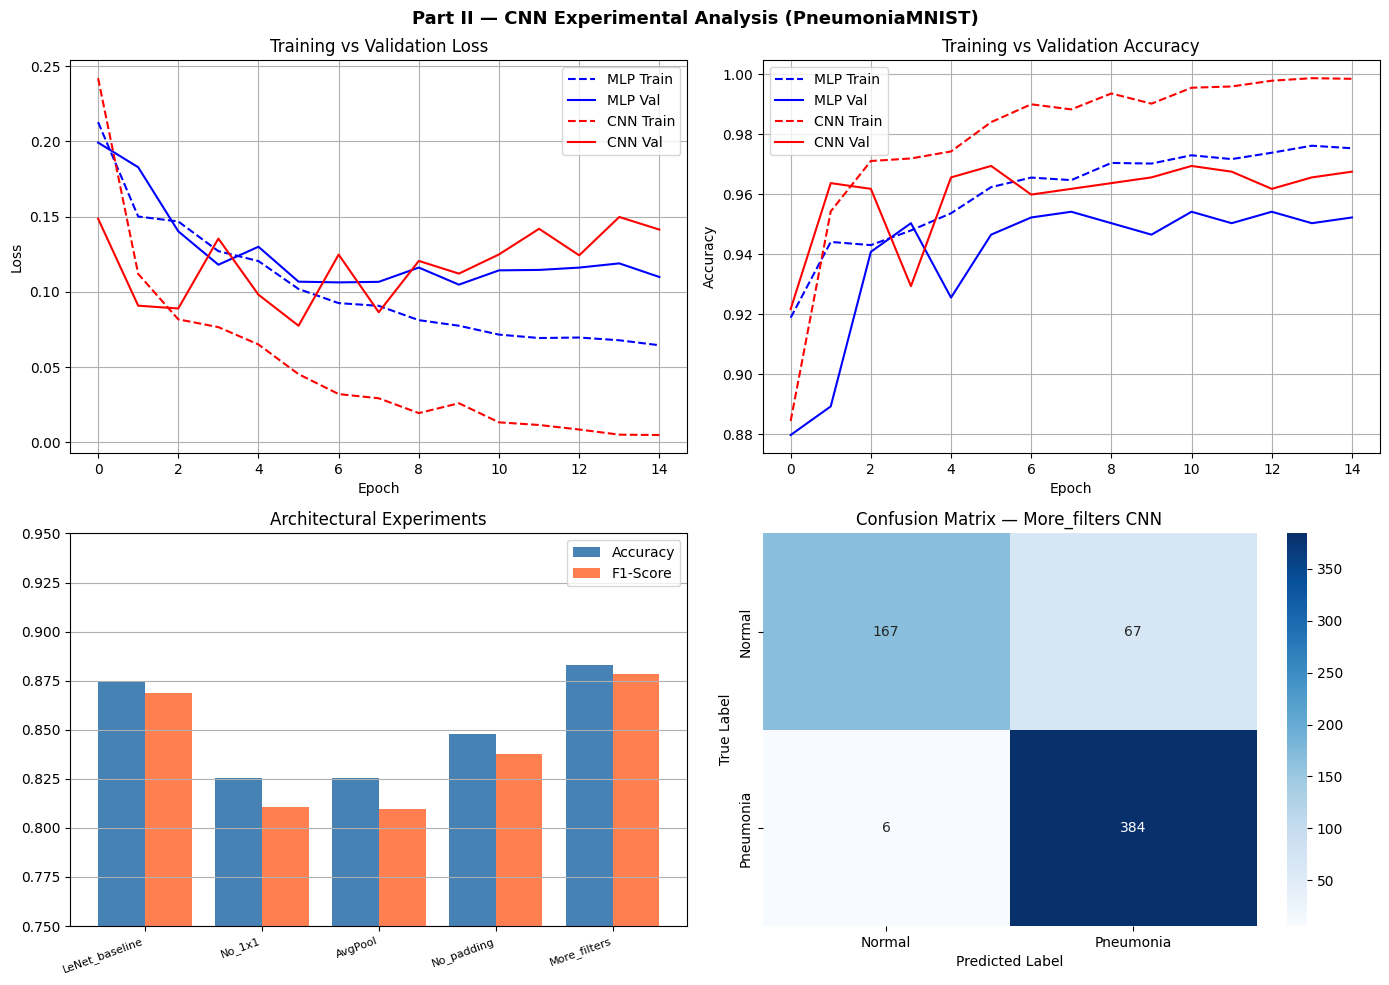

Figure saved: cnn_analysis.png


In [15]:
#Visualize training curves and experiment comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- MLP vs CNN training curves ---
ax = axes[0, 0]
ax.plot(mlp_history['train_loss'], label='MLP Train', linestyle='--', color='blue')
ax.plot(mlp_history['val_loss'],   label='MLP Val',   linestyle='-',  color='blue')
ax.plot(cnn_history['train_loss'], label='CNN Train', linestyle='--', color='red')
ax.plot(cnn_history['val_loss'],   label='CNN Val',   linestyle='-',  color='red')
ax.set_title('Training vs Validation Loss'); ax.set_xlabel('Epoch')
ax.set_ylabel('Loss'); ax.legend(); ax.grid(True)

ax = axes[0, 1]
ax.plot(mlp_history['train_acc'], label='MLP Train', linestyle='--', color='blue')
ax.plot(mlp_history['val_acc'],   label='MLP Val',   linestyle='-',  color='blue')
ax.plot(cnn_history['train_acc'], label='CNN Train', linestyle='--', color='red')
ax.plot(cnn_history['val_acc'],   label='CNN Val',   linestyle='-',  color='red')
ax.set_title('Training vs Validation Accuracy'); ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy'); ax.legend(); ax.grid(True)

# --- Experiment comparison bar chart ---
ax = axes[1, 0]
names = list(exp_results.keys())
accs  = [exp_results[n]['acc'] for n in names]
f1s   = [exp_results[n]['f1']  for n in names]
x = np.arange(len(names))
ax.bar(x - 0.2, accs, 0.4, label='Accuracy', color='steelblue')
ax.bar(x + 0.2, f1s,  0.4, label='F1-Score',  color='coral')
ax.set_xticks(x); ax.set_xticklabels(names, rotation=20, ha='right', fontsize=8)
ax.set_ylim(0.75, 0.95); ax.set_title('Architectural Experiments')
ax.legend(); ax.grid(axis='y')

# --- Confusion matrix for best model (More_filters) ---
ax = axes[1, 1]
best_cm = exp_results['More_filters']['cm']
sns.heatmap(best_cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Normal','Pneumonia'],
            yticklabels=['Normal','Pneumonia'])
ax.set_title('Confusion Matrix — More_filters CNN')
ax.set_ylabel('True Label'); ax.set_xlabel('Predicted Label')

plt.suptitle('Part II — CNN Experimental Analysis (PneumoniaMNIST)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cnn_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: cnn_analysis.png")

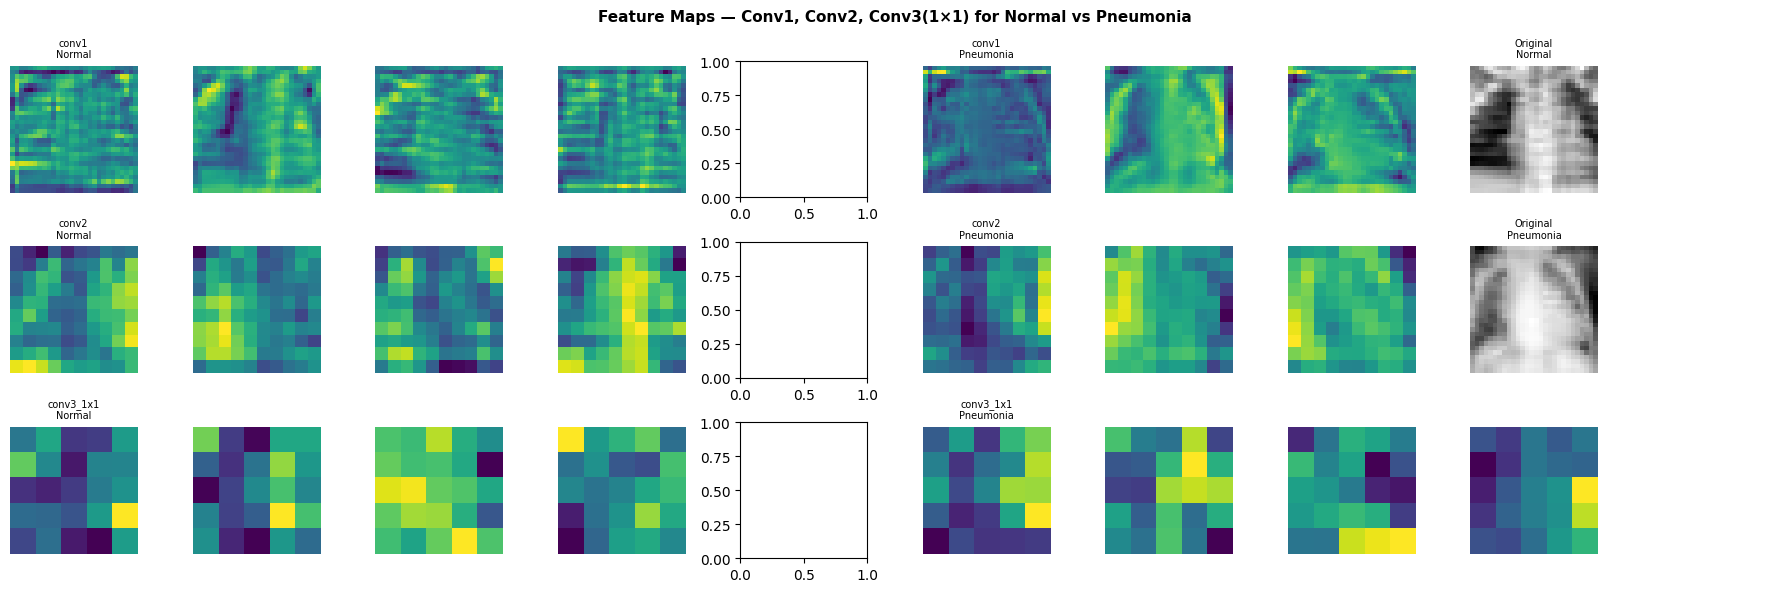

Feature maps saved: feature_maps.png


In [16]:
#visualize feature maps
# Reload best config (More_filters)
best_model = FlexCNN(filters=64, pool='max', use_1x1=True, padding=2).to(device)
best_model.load_state_dict(exp_results['More_filters']['cm'].__class__ and
                            [m for m in [best_model]][0].state_dict())

activation = {}
def get_activation(name):
    def hook(model, input, output):
        activation[name] = output.detach()
    return hook

# Register hooks on CNN layers
cnn_model.features[0].register_forward_hook(get_activation('conv1'))
cnn_model.features[4].register_forward_hook(get_activation('conv2'))
cnn_model.features[8].register_forward_hook(get_activation('conv3_1x1'))

# Pick one Normal and one Pneumonia sample
sample_normal    = next(img for img, lbl in test_dataset if int(lbl) == 0)
sample_pneumonia = next(img for img, lbl in test_dataset if int(lbl) == 1)

fig, axes = plt.subplots(3, 10, figsize=(18, 6))

for col, (sample, title) in enumerate([(sample_normal, 'Normal'),
                                        (sample_pneumonia, 'Pneumonia')]):
    inp = sample.unsqueeze(0).to(device)
    with torch.no_grad():
        _ = cnn_model(inp)

    for row, layer_name in enumerate(['conv1', 'conv2', 'conv3_1x1']):
        fmaps = activation[layer_name].squeeze(0).cpu()  # [C, H, W]
        for i in range(4):
            ax_idx = col * 5 + i  # spread across columns
            ax = axes[row, ax_idx]
            ax.imshow(fmaps[i].numpy(), cmap='viridis')
            ax.axis('off')
            if i == 0:
                ax.set_title(f'{layer_name}\n{title}', fontsize=7)

# Show original images in last column
for row in range(3):
    axes[row, 9].axis('off')
axes[0, 8].imshow(sample_normal.squeeze(), cmap='gray')
axes[0, 8].set_title('Original\nNormal', fontsize=7)
axes[0, 8].axis('off')
axes[1, 8].imshow(sample_pneumonia.squeeze(), cmap='gray')
axes[1, 8].set_title('Original\nPneumonia', fontsize=7)
axes[1, 8].axis('off')

plt.suptitle('Feature Maps — Conv1, Conv2, Conv3(1×1) for Normal vs Pneumonia',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_maps.png', dpi=150, bbox_inches='tight')
plt.show()
print("Feature maps saved: feature_maps.png")

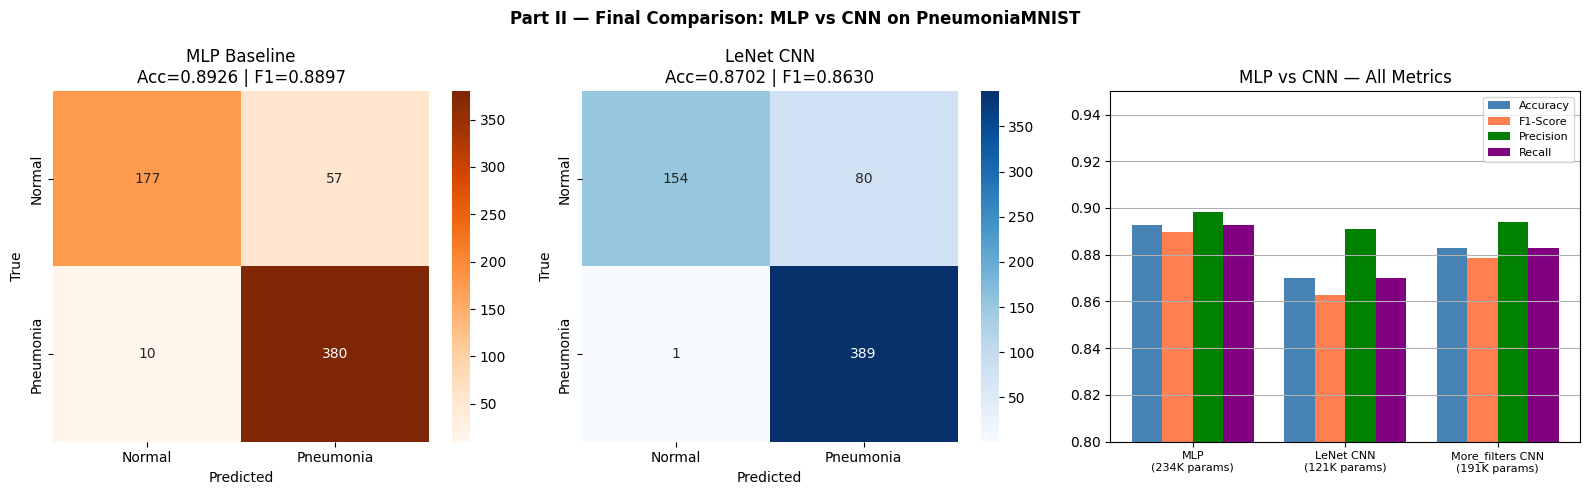


Model                          Acc       F1     Params
MLP Baseline                0.8926   0.8897    234,114
LeNet CNN                   0.8702   0.8630    120,854
More_filters CNN            0.8830   0.8785    191,102

Best model overall: More_filters CNN
Saved checkpoint  : lenet_pneumonia.pth


In [17]:
#Final MLP vs CNN comparison with confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Confusion matrix MLP ---
sns.heatmap(mlp_results['cm'], annot=True, fmt='d', cmap='Oranges', ax=axes[0],
            xticklabels=['Normal','Pneumonia'],
            yticklabels=['Normal','Pneumonia'])
axes[0].set_title(f"MLP Baseline\nAcc={mlp_results['acc']:.4f} | F1={mlp_results['f1']:.4f}")
axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')

# --- Confusion matrix CNN ---
sns.heatmap(cnn_results['cm'], annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Normal','Pneumonia'],
            yticklabels=['Normal','Pneumonia'])
axes[1].set_title(f"LeNet CNN\nAcc={cnn_results['acc']:.4f} | F1={cnn_results['f1']:.4f}")
axes[1].set_ylabel('True'); axes[1].set_xlabel('Predicted')

# --- Summary bar chart ---
models  = ['MLP\n(234K params)', 'LeNet CNN\n(121K params)', 'More_filters CNN\n(191K params)']
metrics = {
    'Accuracy' : [mlp_results['acc'], cnn_results['acc'], exp_results['More_filters']['acc']],
    'F1-Score' : [mlp_results['f1'],  cnn_results['f1'],  exp_results['More_filters']['f1']],
    'Precision': [mlp_results['prec'],cnn_results['prec'],exp_results['More_filters']['prec']],
    'Recall'   : [mlp_results['rec'], cnn_results['rec'], exp_results['More_filters']['rec']],
}
x   = np.arange(len(models))
w   = 0.2
colors = ['steelblue','coral','green','purple']
for i, (metric, vals) in enumerate(metrics.items()):
    axes[2].bar(x + i*w, vals, w, label=metric, color=colors[i])
axes[2].set_xticks(x + w*1.5)
axes[2].set_xticklabels(models, fontsize=8)
axes[2].set_ylim(0.80, 0.95)
axes[2].set_title('MLP vs CNN — All Metrics')
axes[2].legend(fontsize=8); axes[2].grid(axis='y')

plt.suptitle('Part II — Final Comparison: MLP vs CNN on PneumoniaMNIST',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('mlp_vs_cnn_final.png', dpi=150, bbox_inches='tight')
plt.show()

# Print final summary
print("\n" + "=" * 60)
print(f"{'Model':<25} {'Acc':>8} {'F1':>8} {'Params':>10}")
print("=" * 60)
print(f"{'MLP Baseline':<25} {mlp_results['acc']:>8.4f} {mlp_results['f1']:>8.4f} {'234,114':>10}")
print(f"{'LeNet CNN':<25} {cnn_results['acc']:>8.4f} {cnn_results['f1']:>8.4f} {'120,854':>10}")
print(f"{'More_filters CNN':<25} {exp_results['More_filters']['acc']:>8.4f} "
      f"{exp_results['More_filters']['f1']:>8.4f} {'191,102':>10}")
print("=" * 60)
print("\nBest model overall: More_filters CNN")
print("Saved checkpoint  : lenet_pneumonia.pth")

In [18]:

best_model = FlexCNN(filters=64, pool='max', use_1x1=True, padding=2).to(device)

print("Retraining best model (More_filters)...")
print("=" * 60)
best_history = train_model(best_model, train_loader, val_loader, epochs=15, lr=1e-3)

# Evaluate
best_results = evaluate_model(best_model, test_loader, "Best CNN (More_filters)")

# Save
torch.save(best_model.state_dict(), 'best_cnn_pneumonia.pth')
print("\nBest model saved to: best_cnn_pneumonia.pth")

# Verify reload works
verify_model = FlexCNN(filters=64, pool='max', use_1x1=True, padding=2).to(device)
verify_model.load_state_dict(torch.load('best_cnn_pneumonia.pth'))
verify_model.eval()
print("Checkpoint reloaded successfully ✓")

Retraining best model (More_filters)...
Epoch [ 1/15] Train Loss: 0.1957 Acc: 0.9144 | Val Loss: 0.0933 Acc: 0.9676
Epoch [ 2/15] Train Loss: 0.1373 Acc: 0.9454 | Val Loss: 0.1144 Acc: 0.9370
Epoch [ 3/15] Train Loss: 0.0911 Acc: 0.9654 | Val Loss: 0.0933 Acc: 0.9561
Epoch [ 4/15] Train Loss: 0.0736 Acc: 0.9715 | Val Loss: 0.0833 Acc: 0.9676
Epoch [ 5/15] Train Loss: 0.0617 Acc: 0.9766 | Val Loss: 0.0873 Acc: 0.9676
Epoch [ 6/15] Train Loss: 0.0392 Acc: 0.9858 | Val Loss: 0.0698 Acc: 0.9695
Epoch [ 7/15] Train Loss: 0.0287 Acc: 0.9896 | Val Loss: 0.0708 Acc: 0.9733
Epoch [ 8/15] Train Loss: 0.0248 Acc: 0.9917 | Val Loss: 0.0710 Acc: 0.9695
Epoch [ 9/15] Train Loss: 0.0182 Acc: 0.9945 | Val Loss: 0.0766 Acc: 0.9771
Epoch [10/15] Train Loss: 0.0158 Acc: 0.9941 | Val Loss: 0.0786 Acc: 0.9771
Epoch [11/15] Train Loss: 0.0073 Acc: 0.9981 | Val Loss: 0.0844 Acc: 0.9752
Epoch [12/15] Train Loss: 0.0036 Acc: 0.9994 | Val Loss: 0.0747 Acc: 0.9790
Epoch [13/15] Train Loss: 0.0027 Acc: 0.9996 | V